In [2]:
import sys
import os

# Ajoute le dossier parent de `experiments` au path
sys.path.append(os.path.abspath("/Users/clementinechazal/Documents/these/Newcastle/kgd_code"))

import jax
from jax import random
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import jit, vmap
from jax import jacfwd, jacrev
from jax.scipy.stats import multivariate_normal
from modules.kgd_functions import F_P, GradientKernel,KernelGradientDiscrepancy, k_imq, imq_scale_mixtures
from modules.variational_gradient_descent import VariationalGradientDescent

import import_ipynb
from lotka_volterra import gradL_ms,true_params

In [7]:
def grad_log_q0(X):
    return -X

# no need of the function L because gradL is provided
def L(X):
    return 0 

gamma = 10
gradL = lambda X: gradL_ms(X,gamma)

#kernel for VGD 
scales = jnp.array([0.001,0.01,0.1])
m = lambda x,y : imq_scale_mixtures(x,y,scales)
dmx = jit(jacrev(m ,argnums=0))
M = lambda X,xx : vmap(lambda x: vmap(lambda y: m(x, y))(X))(X)
dMx = lambda X,xx : vmap(lambda x: vmap(lambda y: dmx(x, y))(X))(X)

VGD = VariationalGradientDescent(grad_log_q0,L,M,dMx,gradL=gradL)

In [14]:
n = 25
step_size = 1e-4
T = 5000

key = random.PRNGKey(2024)
n_particles = 25
params_init = jnp.stack([true_params] * n_particles, 0)
key, subkey = random.split(key)
X0 = params_init + 1e-5 * random.normal(subkey, params_init.shape)

all_particles = VGD.run_particles(step_size,T,X0,optimise_stepsize = False)
X_fin = all_particles[-1]

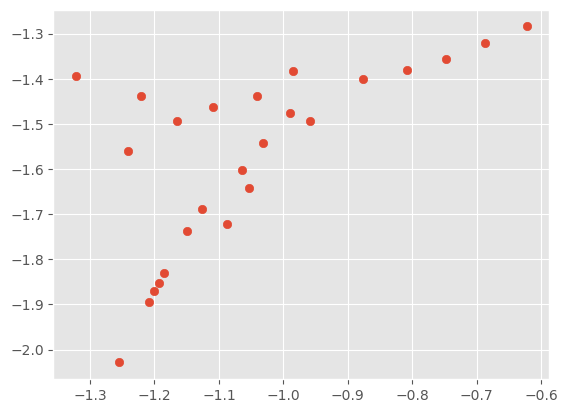

In [15]:
# Final particles position
plt.scatter(X_fin[:,0],X_fin[:,1],label='Final particles')
plt.show()

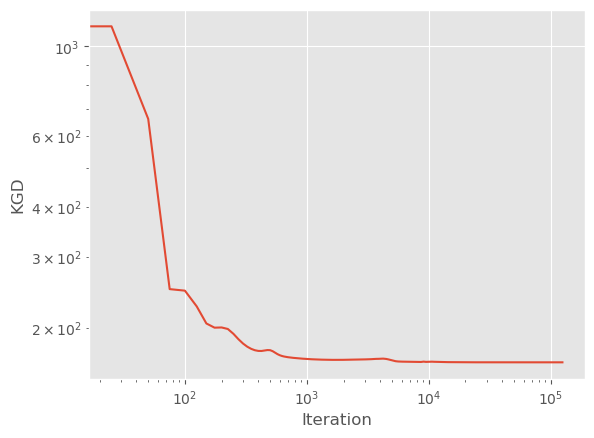

In [18]:
scales = jnp.array([0.001,0.01,0.1])
k = lambda x,y : imq_scale_mixtures(x,y,scales)

k_pq = GradientKernel(VGD.S_PQ,k)
KGD = KernelGradientDiscrepancy(k_pq)

KGD_values = []
for it in range(T):
    KGD_values.append(KGD.evaluate(all_particles[it]))

evaluations_grad_L = jnp.arange(0,T) * n

plt.plot(evaluations_grad_L,KGD_values)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Iteration')
plt.ylabel('KGD')
plt.show()

# Save results

In [22]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open("saved_data/expe3_results.pkl", "rb") as g:
    expe3_results = pickle.load(g)

In [23]:
expe3_results["Variational Gradient Descent"]["X_fin"] = X_fin
expe3_results["Variational Gradient Descent"]["KGD_values"] = KGD_values
expe3_results["Variational Gradient Descent"]["gradL_eval"] = evaluations_grad_L

In [24]:
import pickle

# Sauvegarde dans un fichier binaire
with open("saved_data/expe3_results.pkl", "wb") as gg:
    pickle.dump(expe3_results, gg)